Evolving 490000 points for 10000 steps...
Detecting periods up to 99...


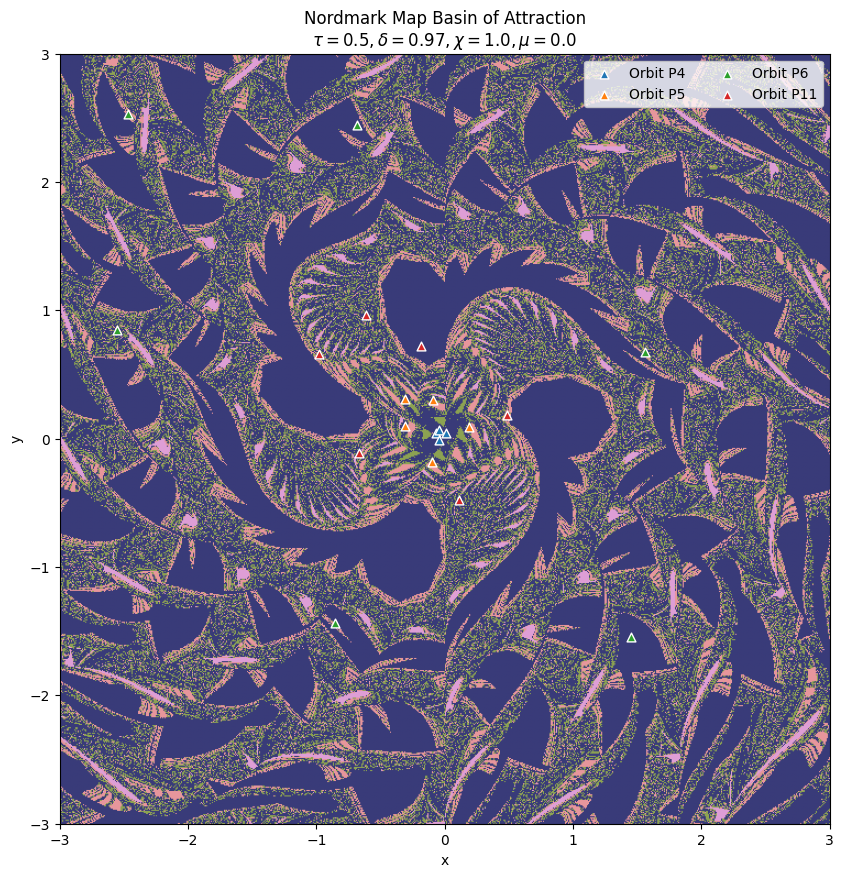

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ==========================================
# 1. PARAMETERS & CONFIGURATION
# ==========================================
tau, delta, chi, mu = 0.5, 0.97, 1.0, 0.0
x_range = [-3, 3]
y_range = [-3, 3]
res = 700

Nmax = 10000        # Transient iterations
N0 = 99             # Period detection window
tol = 1e-14         # Norm tolerance
div_thresh = 1e2    # Divergence threshold

# ==========================================
# 2. GRID SETUP (Vectorized)
# ==========================================
x_vec = np.linspace(x_range[0], x_range[1], res)
y_vec = np.linspace(y_range[1], y_range[0], res) # Standard image orientation
X, Y = np.meshgrid(x_vec, y_vec)
x = X.flatten()
y = Y.flatten()

# ==========================================
# 3. VECTORIZED PHYSICS ENGINE
# ==========================================
def evolve_step(x_curr, y_curr):
    # Vectorized conditional: piecewise map logic
    mask = x_curr <= 0
    xn = np.empty_like(x_curr)
    
    # Case: x <= 0
    xn[mask] = tau * x_curr[mask] + y_curr[mask]
    # Case: x > 0 (using maximum to handle potential precision issues near 0)
    xn[~mask] = tau * x_curr[~mask] + y_curr[~mask] - chi * np.sqrt(np.maximum(x_curr[~mask], 0))
    
    yn = -delta * x_curr + mu
    return xn, yn

# ==========================================
# 4. SIMULATION: TRANSIENT & CLASSIFICATION
# ==========================================
print(f"Evolving {len(x)} points for {Nmax} steps...")
for _ in range(Nmax):
    x, y = evolve_step(x, y)

# Store final state z_final for period comparison
zf_x, zf_y = x.copy(), y.copy()
periods = np.zeros_like(x, dtype=int)
divergent = (np.abs(x) > div_thresh) | np.isnan(x)

# Period detection loop (up to N0 steps)
print(f"Detecting periods up to {N0}...")
for j in range(1, N0 + 1):
    x, y = evolve_step(x, y)
    
    # Classification logic: classify as period j if it returns to z_final
    dist = np.sqrt((x - zf_x)**2 + (y - zf_y)**2)
    mask_found = (periods == 0) & (dist < tol)
    periods[mask_found] = j
    
    # Update divergence mask
    divergent |= (np.abs(x) > div_thresh) | np.isnan(x)

# Mark divergent points
periods[divergent] = -1

# ==========================================
# 5. VISUALIZATION
# ==========================================
basin_matrix = periods.reshape((res, res))

# Define color map (Black for divergence, varying colors for periods)
unique_periods = np.unique(basin_matrix)
cmap = plt.get_cmap('tab20b', len(unique_periods))
if -1 in unique_periods:
    colors = cmap(np.linspace(0, 1, len(unique_periods)))
    colors[np.where(unique_periods == -1)[0][0]] = [0, 0, 0, 1] # Black for -1
    cmap = ListedColormap(colors)

plt.figure(figsize=(10, 10))
plt.imshow(basin_matrix, extent=[*x_range, *y_range], cmap=cmap)

# Overlay Known Periodic Orbits
known_orbits = {
    4:  [(-0.0659, 0.0429), (-0.0428, 0.0653), (0.0097, 0.0424), (-0.0434, -0.0096)],
    5:  [(-0.3124, 0.0976), (-0.3085, 0.3093), (-0.0918, 0.3054), (0.1861, 0.0909), (-0.0986, -0.1842)],
    6:  [(1.4535, -1.5415), (-0.8576, -1.4390), (-2.5538, 0.8490), (-2.4709, 2.5283), (-0.6840, 2.4462), (1.5571, 0.6771)],
    11: [(-0.1829, 0.7190), (0.4812, 0.1811), (0.1130, -0.4764), (-0.6656, -0.1118), (-0.9772, 0.6590), (-0.6113, 0.9674)]
}

for p, pts in known_orbits.items():
    pts = np.array(pts)
    plt.scatter(pts[:, 0], pts[:, 1], s=40, edgecolors='white', marker='^', label=f'Orbit P{p}')

plt.title(f"Nordmark Map Basin of Attraction\n$\\tau={tau}, \\delta={delta}, \\chi={chi}, \\mu={mu}$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc='upper right', ncol=2)
plt.show()

Evolving 490000 points for 10000 steps...
Detecting periods up to 99...


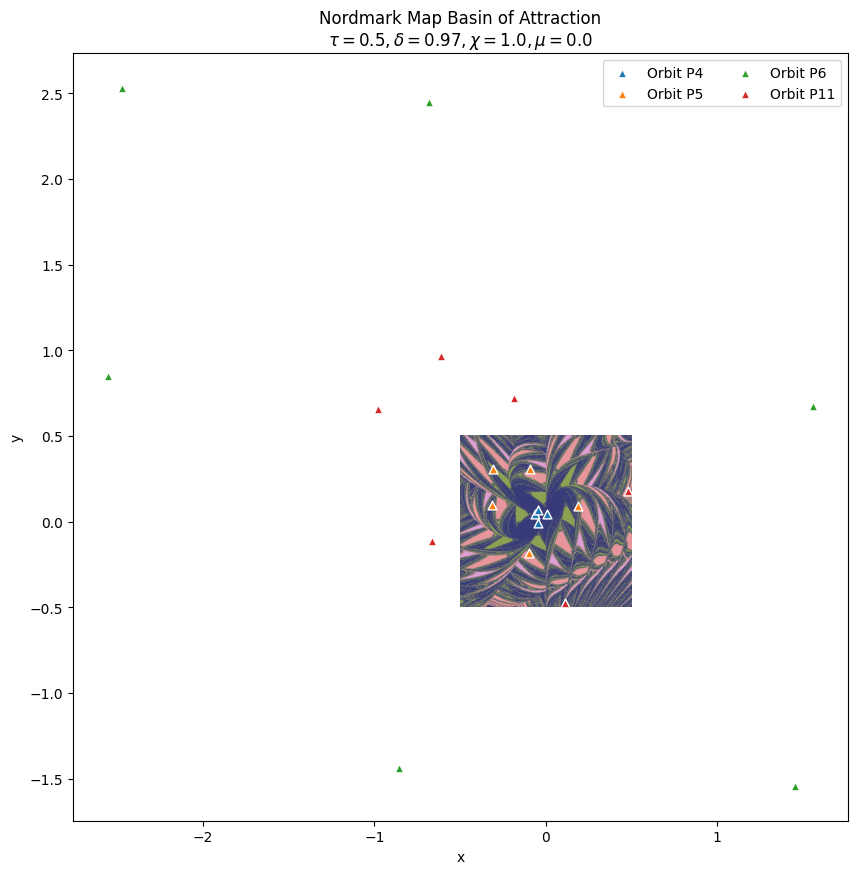

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ==========================================
# 1. PARAMETERS & CONFIGURATION
# ==========================================
tau, delta, chi, mu = 0.5, 0.97, 1.0, 0.0
x_range = [-0.5, 0.5]
y_range = [-0.5, 0.5]
res = 700

Nmax = 10000        # Transient iterations
N0 = 99             # Period detection window
tol = 1e-14         # Norm tolerance
div_thresh = 1e2    # Divergence threshold

# ==========================================
# 2. GRID SETUP (Vectorized)
# ==========================================
x_vec = np.linspace(x_range[0], x_range[1], res)
y_vec = np.linspace(y_range[1], y_range[0], res) # Standard image orientation
X, Y = np.meshgrid(x_vec, y_vec)
x = X.flatten()
y = Y.flatten()

# ==========================================
# 3. VECTORIZED PHYSICS ENGINE
# ==========================================
def evolve_step(x_curr, y_curr):
    # Vectorized conditional: piecewise map logic
    mask = x_curr <= 0
    xn = np.empty_like(x_curr)
    
    # Case: x <= 0
    xn[mask] = tau * x_curr[mask] + y_curr[mask]
    # Case: x > 0 (using maximum to handle potential precision issues near 0)
    xn[~mask] = tau * x_curr[~mask] + y_curr[~mask] - chi * np.sqrt(np.maximum(x_curr[~mask], 0))
    
    yn = -delta * x_curr + mu
    return xn, yn

# ==========================================
# 4. SIMULATION: TRANSIENT & CLASSIFICATION
# ==========================================
print(f"Evolving {len(x)} points for {Nmax} steps...")
for _ in range(Nmax):
    x, y = evolve_step(x, y)

# Store final state z_final for period comparison
zf_x, zf_y = x.copy(), y.copy()
periods = np.zeros_like(x, dtype=int)
divergent = (np.abs(x) > div_thresh) | np.isnan(x)

# Period detection loop (up to N0 steps)
print(f"Detecting periods up to {N0}...")
for j in range(1, N0 + 1):
    x, y = evolve_step(x, y)
    
    # Classification logic: classify as period j if it returns to z_final
    dist = np.sqrt((x - zf_x)**2 + (y - zf_y)**2)
    mask_found = (periods == 0) & (dist < tol)
    periods[mask_found] = j
    
    # Update divergence mask
    divergent |= (np.abs(x) > div_thresh) | np.isnan(x)

# Mark divergent points
periods[divergent] = -1

# ==========================================
# 5. VISUALIZATION
# ==========================================
basin_matrix = periods.reshape((res, res))

# Define color map (Black for divergence, varying colors for periods)
unique_periods = np.unique(basin_matrix)
cmap = plt.get_cmap('tab20b', len(unique_periods))
if -1 in unique_periods:
    colors = cmap(np.linspace(0, 1, len(unique_periods)))
    colors[np.where(unique_periods == -1)[0][0]] = [0, 0, 0, 1] # Black for -1
    cmap = ListedColormap(colors)

plt.figure(figsize=(10, 10))
plt.imshow(basin_matrix, extent=[*x_range, *y_range], cmap=cmap)

# Overlay Known Periodic Orbits
known_orbits = {
    4:  [(-0.0659, 0.0429), (-0.0428, 0.0653), (0.0097, 0.0424), (-0.0434, -0.0096)],
    5:  [(-0.3124, 0.0976), (-0.3085, 0.3093), (-0.0918, 0.3054), (0.1861, 0.0909), (-0.0986, -0.1842)],
    6:  [(1.4535, -1.5415), (-0.8576, -1.4390), (-2.5538, 0.8490), (-2.4709, 2.5283), (-0.6840, 2.4462), (1.5571, 0.6771)],
    11: [(-0.1829, 0.7190), (0.4812, 0.1811), (0.1130, -0.4764), (-0.6656, -0.1118), (-0.9772, 0.6590), (-0.6113, 0.9674)]
}

for p, pts in known_orbits.items():
    pts = np.array(pts)
    plt.scatter(pts[:, 0], pts[:, 1], s=40, edgecolors='white', marker='^', label=f'Orbit P{p}')

plt.title(f"Nordmark Map Basin of Attraction\n$\\tau={tau}, \\delta={delta}, \\chi={chi}, \\mu={mu}$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc='upper right', ncol=2)
plt.show()